## Data Cleaning & Tidy Process

### Step 1: Load Data and Convert Wide Data to Long Format

The dataset is loaded using `pd.read_csv()`, then reshaped from wide to long format using `pd.melt()`. This transformation converts multiple year_gdp and gdp_value columns into a single year_gdp column and a corresponding gdp_value column, so that each row represents one department–year observation. This structure makes the data tidy and easier to analyze, filter, and visualize.

In [12]:
import pandas as pd
Fed_RD = pd.read_csv("data/fed_rd_year&gdp.csv")
Fed_RD = pd.melt(Fed_RD, id_vars=['department'], var_name='year_gdp', value_name='gdp_value')
Fed_RD


,department,year_gdp,gdp_value
0,DHS,1976_gdp1790000000000.0,NaN
1,DOC,1976_gdp1790000000000.0,"819,000,000"
2,DOD,1976_gdp1790000000000.0,"35,696,000,000"
3,DOE,1976_gdp1790000000000.0,"10,882,000,000"
4,DOT,1976_gdp1790000000000.0,"1,142,000,000"
...,...,...,...
583,NIH,2017_gdp19177000000000.0,"33,052,000,000"
584,NSF,2017_gdp19177000000000.0,"6,040,000,000"
585,Other,2017_gdp19177000000000.0,"1,553,000,000"
586,USDA,2017_gdp19177000000000.0,"2,625,000,000"


### Step 2: Split and Clean Year and GDP Variables

The year_gdp column is split into two separate variables, year and gdp, using `str.split()`. After that, `str.replace()` removes the text "gdp" and the original year_gdp column is dropped. This results in a cleaner dataset where each variable has its own column, making the data easier to analyze and consistent with tidy data principles.

In [13]:
Fed_RD[['year', 'gdp']] = Fed_RD['year_gdp'].str.split('_', expand=True)
Fed_RD['gdp'] = Fed_RD['gdp'].str.replace('gdp', '')
Fed_RD = Fed_RD.drop(columns=['year_gdp'])
Fed_RD

,department,gdp_value,year,gdp
0,DHS,NaN,1976,1790000000000.0
1,DOC,"819,000,000",1976,1790000000000.0
2,DOD,"35,696,000,000",1976,1790000000000.0
3,DOE,"10,882,000,000",1976,1790000000000.0
4,DOT,"1,142,000,000",1976,1790000000000.0
...,...,...,...,...
583,NIH,"33,052,000,000",2017,19177000000000.0
584,NSF,"6,040,000,000",2017,19177000000000.0
585,Other,"1,553,000,000",2017,19177000000000.0
586,USDA,"2,625,000,000",2017,19177000000000.0


### Step 3: Rename and Format Final Variables

In the final cleaning step, the columns are renamed to `Department`, `Year`, `RD_Budget`, and `GDP` to make them easier to read. Then `Year`, `RD_Budget` and `GDP` are converted to numeric format, and the display format is changed so the values appear as regular numbers instead of scientific notation. Finally, the columns are reordered to a logical structure (Department, Year, RD_Budget, GDP), resulting in a clean and well-organized dataset that is ready for analysis.

In [20]:
Fed_RD = Fed_RD.rename(columns={'department': 'Department', 'year': 'Year', 'gdp_value': 'RD_Budget', 'gdp': 'GDP'})
Fed_RD['Year'] = pd.to_numeric(Fed_RD['Year'])
Fed_RD['RD_Budget'] = pd.to_numeric(Fed_RD['RD_Budget'])
Fed_RD['GDP'] = pd.to_numeric(Fed_RD['GDP'])
pd.options.display.float_format = '{:,.0f}'.format
Fed_RD = Fed_RD[['Department', 'Year', 'RD_Budget', 'GDP']]
Fed_RD

,Department,Year,RD_Budget,GDP
0,DHS,1976,NaN,"1,790,000,000,000"
1,DOC,1976,"819,000,000","1,790,000,000,000"
2,DOD,1976,"35,696,000,000","1,790,000,000,000"
3,DOE,1976,"10,882,000,000","1,790,000,000,000"
4,DOT,1976,"1,142,000,000","1,790,000,000,000"
...,...,...,...,...
583,NIH,2017,"33,052,000,000","19,177,000,000,000"
584,NSF,2017,"6,040,000,000","19,177,000,000,000"
585,Other,2017,"1,553,000,000","19,177,000,000,000"
586,USDA,2017,"2,625,000,000","19,177,000,000,000"


## Visualizations

### Heatmap: GDP by Department and Year

This chart gives an overall comparison of GDP across departments over time. The color differences make it easier to see which departments consistently have higher GDP values and which remain lower across the full dataset.

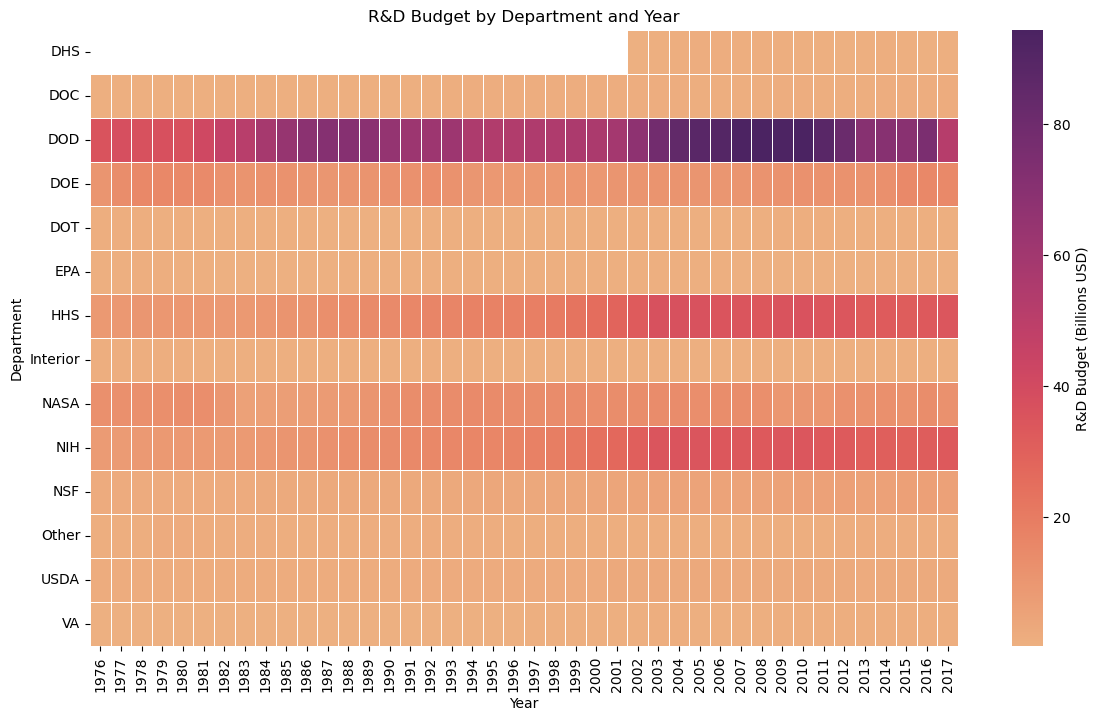

In [ ]:
# Load packages
import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot table for heatmap
pivot_GDP = pd.pivot_table(Fed_RD, values = 'RD_Budget', index = 'Department', columns = 'Year') / 1e9

plt.figure(figsize = (14,8))

# Create heatmap
ax = sns.heatmap(pivot_GDP, cmap = "flare", linewidths = 0.5)

# Customize colorbar 
cbar = ax.collections[0].colorbar
cbar.set_label("R&D Budget (Billions USD)")

plt.title("R&D Budget by Department and Year")
plt.xlabel("Year")
plt.ylabel("Department")

plt.show()

### Heatmap: Last 10 Years of GDP by Department

This heatmap focuses only on the most recent 10 years in the dataset. The labeled values help compare year-to-year changes within each department and highlight where GDP increased or decreased in the most recent period.

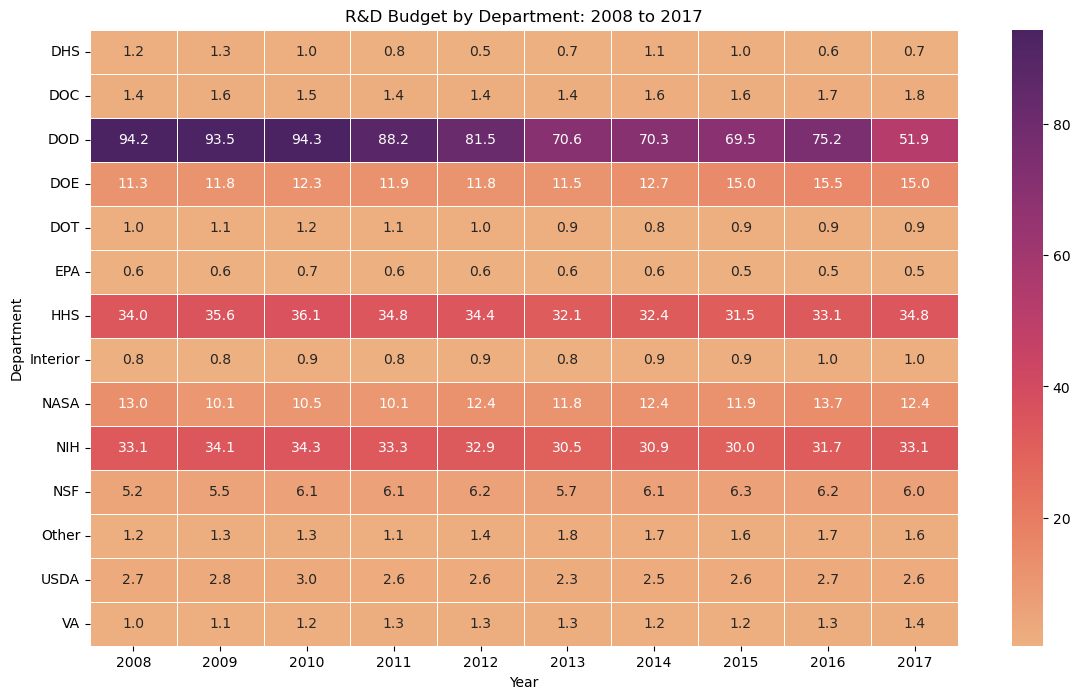

In [ ]:
# Filter for the last 10 years of data
max_year = Fed_RD['Year'].max()
last_10_df = Fed_RD[Fed_RD['Year'] > (max_year - 10)]

# Pivot the filtered data
pivot_GDP = pd.pivot_table(last_10_df, values='RD_Budget', index='Department', columns='Year') / 1e9

# Create heatmap for the last 10 years
plt.figure(figsize = (14, 8))
sns.heatmap(pivot_GDP, annot=True, fmt = ".1f", cmap = "flare", linewidths = 0.5)

plt.title(f"R&D Budget by Department: {max_year-9} to {max_year}")
plt.show()

### Line Chart: GDP Growth Trend in the United States (1976–2017)

This visualization shows the growth of the United States' GDP over time, measured in trillions of dollars. The data reveals a steady upward trend from 1976 to 2017, reflecting long-term economic expansion. While there are minor fluctuations, such as a slight dip around 2008-2009, the overall pattern demonstrates consistent growth.

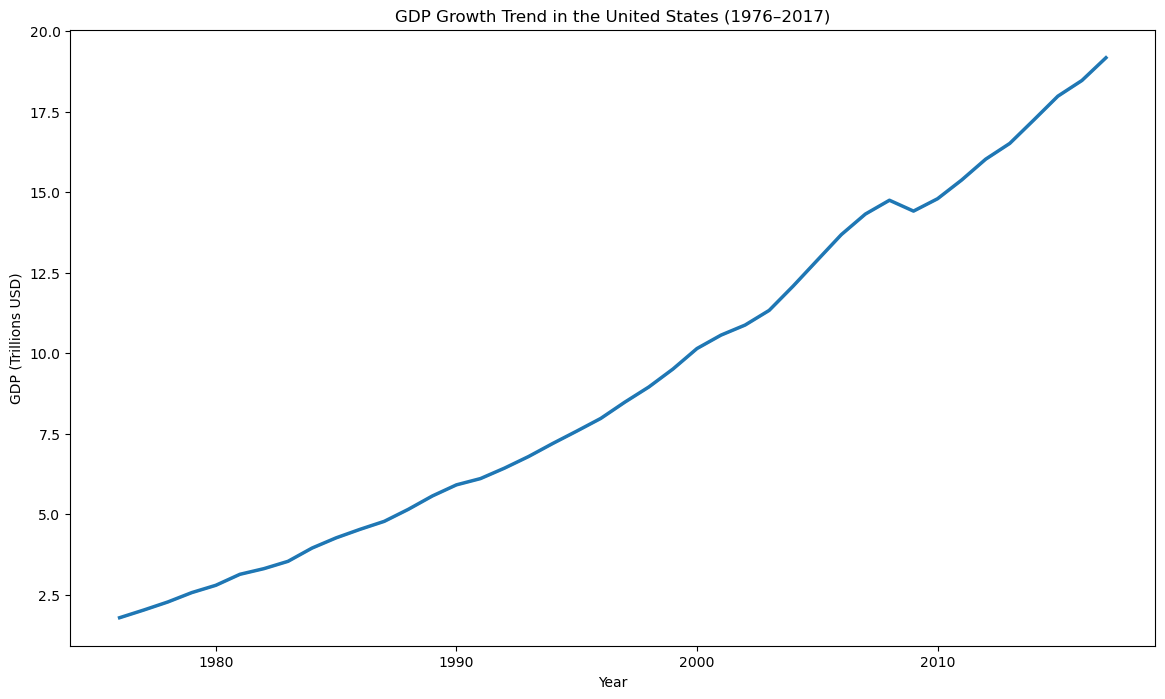

In [ ]:

plt.figure(figsize = (14,8))

# Convert GDP to trillions for better readability
Fed_RD['GDP_trillions'] = Fed_RD['GDP'] / 1e12

# Create line plot for GDP growth trend
sns.lineplot(data=Fed_RD, x = 'Year', y = 'GDP_trillions', linewidth = 2.5)

plt.title("GDP Growth Trend in the United States (1976–2017)")
plt.ylabel("GDP (Trillions USD)")
plt.show()

### Pivot Table: Average GDP by Department

This pivot table takes the mean GDP by department across all years. The department of defense on average had the largest GDP with an average of $64 billon. The lowest average GDP was roughly $733 million belonging to the department of Veterans Affairs.

In [ ]:
# Create pivot table to analyze average R&D budget by department
pivot_table_GDP = pd.pivot_table(
    Fed_RD,
    values='RD_Budget',
    index='Department',
    aggfunc='mean'
).sort_values(by='RD_Budget', ascending=False)


pivot_table_GDP

,GDP
Department,
DOD,"64,685,190,476"
HHS,"22,296,761,905"
NIH,"21,117,571,429"
NASA,"12,140,261,905"
DOE,"11,883,380,952"
NSF,"4,038,809,524"
USDA,"2,380,809,524"
Other,"1,494,761,905"
DOC,"1,231,500,000"
